<a href="https://colab.research.google.com/github/reezyhudson865/DataProjects/blob/main/RHudson_Mortality_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data 202 Module 3 Lab**

The following notebook is a lab completed in an undergrad Data Science class at UT-Knoxville in the Spring 2026 semester. The lab includes data imports, normalization and cleaning, and visualization. The lab objective was outlined by the professor. All rights reserved.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import csv
#uploaded csv to jupyter lab for easy insertion and reading in this notebook

df = pd.read_csv("mortality.csv")
df.head(5)

,Year,Age Group,Deaths_per_100K,Population,Deaths
0,1900,1-4 Years,307.450712,199585,613
1,1900,5-9 Years,89.715328,204569,183
2,1900,10-14 Years,76.487699,199297,152
3,1900,15-19 Years,143.688192,202302,290
4,1900,20-29 Years,112.957884,201627,227


In [ ]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

In [ ]:
num_unique_age_groups = df['Age Group'].nunique()
print("Number of unique age groups:", num_unique_age_groups)

In [ ]:
min_year = df["Year"].min()
max_year = df["Year"].max()
print(f"Year range: {min_year} - {max_year}")

In [ ]:
print(df.dtypes)

Year                 int64
Age Group           object
Deaths_per_100K    float64
Population          object
Deaths               int64
dtype: object


In [ ]:
df['Population'] = df['Population'].astype(str)
df['Population'] = df['Population'].str.replace(r'\D', '', regex=True)
df['Population'] = df['Population'].astype(int)
#must convert all to str first in order to change all to int

df["Deaths_per_100K"] = pd.to_numeric(df['Deaths_per_100K'])

print(df.dtypes)

Year                 int64
Age Group           object
Deaths_per_100K    float64
Population           int64
Deaths               int64
dtype: object


In [ ]:
df[df["Age Group"] == "1-4 Years"].head(5)
df[df["Age Group"] == "50-59 Years"].head(5)

,Year,Age Group,Deaths_per_100K,Population,Deaths
7,1900,50-59 Years,374.126233,198313,741
16,1901,50-59 Years,399.297542,197426,788
25,1902,50-59 Years,145.700000,200044,807
34,1903,50-59 Years,403.924540,199864,807
43,1904,50-59 Years,411.731032,203386,837


In [ ]:
df_1910_1920 = df[(df["Year"] >= 1910) & (df["Year"] <= 1920)]
df_1910_1920

,Year,Age Group,Deaths_per_100K,Population,Deaths
90,1910,1-4 Years,304.385010,203428,619
91,1910,5-9 Years,58.936613,207447,122
92,1910,10-14 Years,71.648058,208142,149
93,1910,15-19 Years,122.098564,205781,251
94,1910,20-29 Years,102.298094,201455,206
...,...,...,...,...,...
184,1920,20-29 Years,111.465141,209680,233
185,1920,30-39 Years,190.367653,213493,406
186,1920,40-49 Years,211.767154,214877,455
187,1920,50-59 Years,422.297737,209697,885


In [ ]:
df_1918 = df_1910_1920[df_1910_1920["Year"] == 1918]
df_1918

,Year,Age Group,Deaths_per_100K,Population,Deaths
162,1918,1-4 Years,275.909739,207157,571
163,1918,5-9 Years,88.371663,213174,188
164,1918,10-14 Years,80.361797,212685,170
165,1918,15-19 Years,110.816298,208108,230
166,1918,20-29 Years,112.137068,208768,234
167,1918,30-39 Years,205.626796,210358,432
168,1918,40-49 Years,178.617542,209835,374
169,1918,50-59 Years,397.193972,209108,830
170,1918,60-69 Years,378.666694,211531,800


In [ ]:
top_10 = df.sort_values(by='Deaths_per_100K', ascending=False).head(10)
top_10

,Year,Age Group,Deaths_per_100K,Population,Deaths
53,1905,60-69 Years,425.792789,203523,866
142,1915,50-59 Years,424.495501,203143,862
187,1920,50-59 Years,422.297737,209697,885
124,1913,50-59 Years,419.981814,209014,877
61,1906,50-59 Years,418.041915,199394,833
133,1914,50-59 Years,417.486170,204109,852
440,1948,60-69 Years,413.903986,227207,940
17,1901,60-69 Years,411.838174,196937,811
43,1904,50-59 Years,411.731032,203386,837
106,1911,50-59 Years,408.810026,208554,852


In [ ]:
avg_by_year = df.groupby('Year')['Deaths_per_100K'].mean().reset_index()
avg_by_year

,Year,Deaths_per_100K
0,1900,209.545750
1,1901,208.171909
2,1902,177.351719
3,1903,210.279584
4,1904,206.375456
5,1905,207.396053
6,1906,211.603516
7,1907,197.989385
8,1908,205.624784
9,1909,209.539550


In [ ]:
avg_by_age = df.groupby('Age Group')['Deaths_per_100K'].mean().reset_index()
avg_by_age

,Age Group,Deaths_per_100K
0,1-4 Years,289.701232
1,10-14 Years,66.105592
2,15-19 Years,109.807750
3,20-29 Years,106.575786
4,30-39 Years,187.595445
5,40-49 Years,188.656306
6,5-9 Years,63.501306
7,50-59 Years,384.630300
8,60-69 Years,386.568228


In [ ]:
median_death_rate = df['Deaths_per_100K'].median()
print("Median Deaths_per_100K:", median_death_rate)

Median Deaths_per_100K: 176.02377992977463


In [ ]:
def get_agegroup_stats(age_group):
    subset = df[df["Age Group"] == age_group]["Deaths_per_100K"]

    return {
        "Age Group": age_group,
        "Mean": subset.mean(),
        "Median": subset.median(),
        "Max": subset.max()
    }

stats_1_4 = get_agegroup_stats("1-4 Years")
stats_1_4

{'Age Group': '1-4 Years',
 'Mean': np.float64(289.70123174750455),
 'Median': 287.1995293947973,
 'Max': 325.6591613398799}

In [ ]:
stats_15_19 = get_agegroup_stats("15-19 Years")
stats_15_19

{'Age Group': '15-19 Years',
 'Mean': np.float64(109.80774997442249),
 'Median': 110.81629840729627,
 'Max': 143.68819223261087}

In [ ]:
death_rates = df['Deaths_per_100K'].to_numpy()

In [ ]:
mean_rate = np.mean(death_rates)
std_rate = np.std(death_rates)
max_rate = np.max(death_rates)

print("Mean Death Rate:", mean_rate)
print("Standard Deviation:", std_rate)
print("Maximum Death Rate:", max_rate)

Mean Death Rate: 198.12688279432467
Standard Deviation: 122.03391329972295
Maximum Death Rate: 425.792788518158


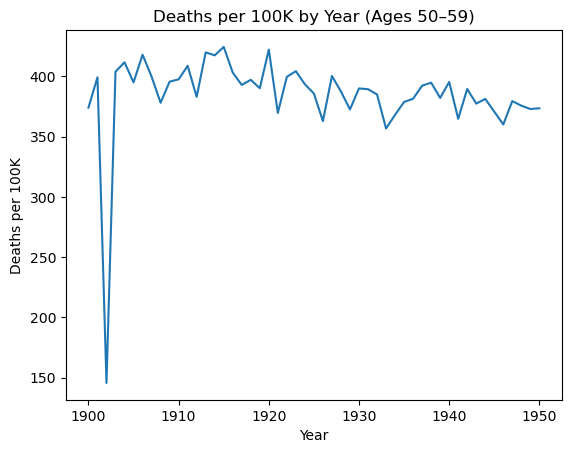

In [ ]:
age_50_59 = df[df['Age Group'] == '50-59 Years']

plt.figure()
plt.plot(age_50_59['Year'], age_50_59['Deaths_per_100K'])
plt.xlabel("Year")
plt.ylabel("Deaths per 100K")
plt.title("Deaths per 100K by Year (Ages 50–59)")
plt.show()

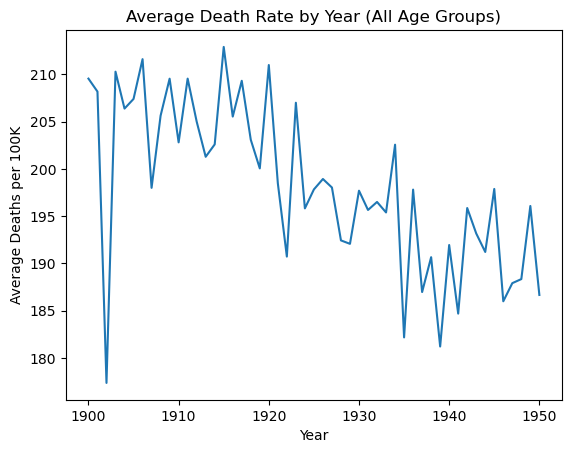

In [ ]:
avg_by_year = df.groupby('Year')['Deaths_per_100K'].mean()

plt.figure()
plt.plot(avg_by_year.index, avg_by_year.values)
plt.xlabel("Year")
plt.ylabel("Average Deaths per 100K")
plt.title("Average Death Rate by Year (All Age Groups)")
plt.show()

# Reflection

Death rates declined very heavily in 1902, then reached another low again in 1939. However, the average rebounded heavily in the following respective year, around 1904, then an all time peal in 1915. The age groups most effected were the 50-59 and 60-69. Fixing the data formatting issues allowed me to cohesively perform analyses and observations across the data frame, whereas the syntax differences would have made it far more difficult and less uniform, requiring more code and cleaning along the way.

The main trends I saw in the data were that death averages were higher in the older age groups, specifically from age 50 and up. Across all age groups however, mortality rates seem to have gotten lower in the latter most years, which the majority of all age groups seeing an overwhelming peak of deaths at the beginning of the data collection around 1900. However, despite general downward trends, all age groups experienced repetitive peaks and valleys of average death totals from 1900-1950, with seemingly no uniform linear relationship between years and averages.